In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings("ignore")

df_raw = pd.read_csv("../data/raw/athlete_sessions.csv")
SIGNALS = ["heart_rate","hrv","reaction_time_ms","decision_accuracy",
           "pupil_diameter","blink_rate","saccade_velocity",
           "cortisol_proxy","focus_score","movement_efficiency"]
agg = {s: "mean" for s in SIGNALS}
agg["state"] = "first"
agg["state_label"] = "first"
df = df_raw.groupby("session_id").agg(agg).reset_index()

X      = df[SIGNALS].values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)
y      = df["state"].values
labels = df["state_label"].values

COLOR_MAP = {"fatigued":"#E24B4A","normal":"#EF9F27","zone":"#1D9E75"}
print(f"Data: {X_sc.shape} | States: {np.unique(labels)}")

Data: (2100, 10) | States: ['fatigued' 'normal' 'zone']


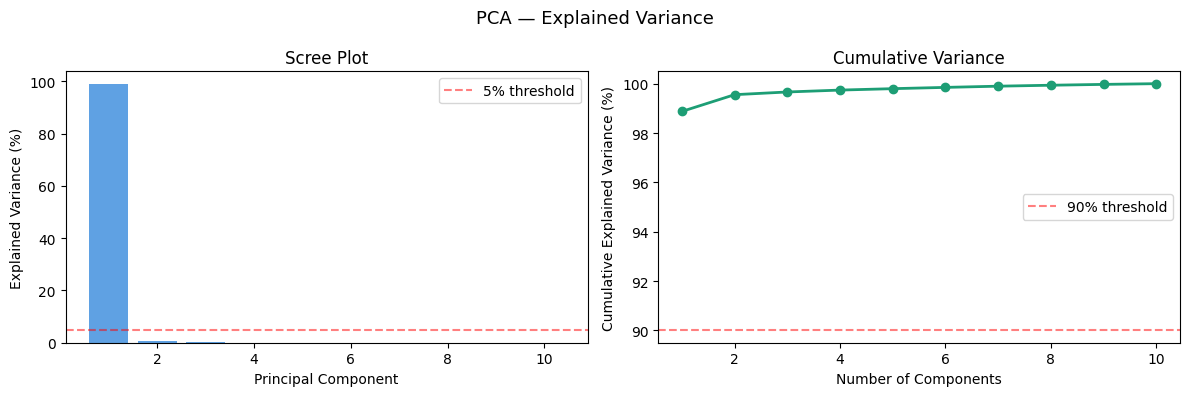


1 components explain 90%+ of variance


In [3]:
pca_full = PCA(random_state=42)
pca_full.fit(X_sc)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(evr)+1), evr*100, color="#378ADD", alpha=0.8)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_title("Scree Plot")
ax1.axhline(5, color="red", linestyle="--", alpha=0.5, label="5% threshold")
ax1.legend()

ax2.plot(range(1, len(cum)+1), cum*100, "o-", color="#1D9E75", linewidth=2)
ax2.axhline(90, color="red", linestyle="--", alpha=0.5, label="90% threshold")
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Explained Variance (%)")
ax2.set_title("Cumulative Variance")
ax2.legend()

plt.suptitle("PCA — Explained Variance", fontsize=13)
plt.tight_layout()
plt.savefig("../data/scree_plot.png", bbox_inches="tight")
plt.show()

n_90 = np.argmax(cum >= 0.90) + 1
print(f"\n{n_90} components explain 90%+ of variance")

In [4]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_sc)

fig = px.scatter(
    x=X_2d[:,0], y=X_2d[:,1],
    color=labels,
    color_discrete_map=COLOR_MAP,
    labels={
        "x": f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)",
        "y": f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)"
    },
    title="PCA — Athlete state separation in 2D feature space",
    opacity=0.65
)
fig.update_traces(marker_size=5)
fig.update_layout(height=500)
fig.show()

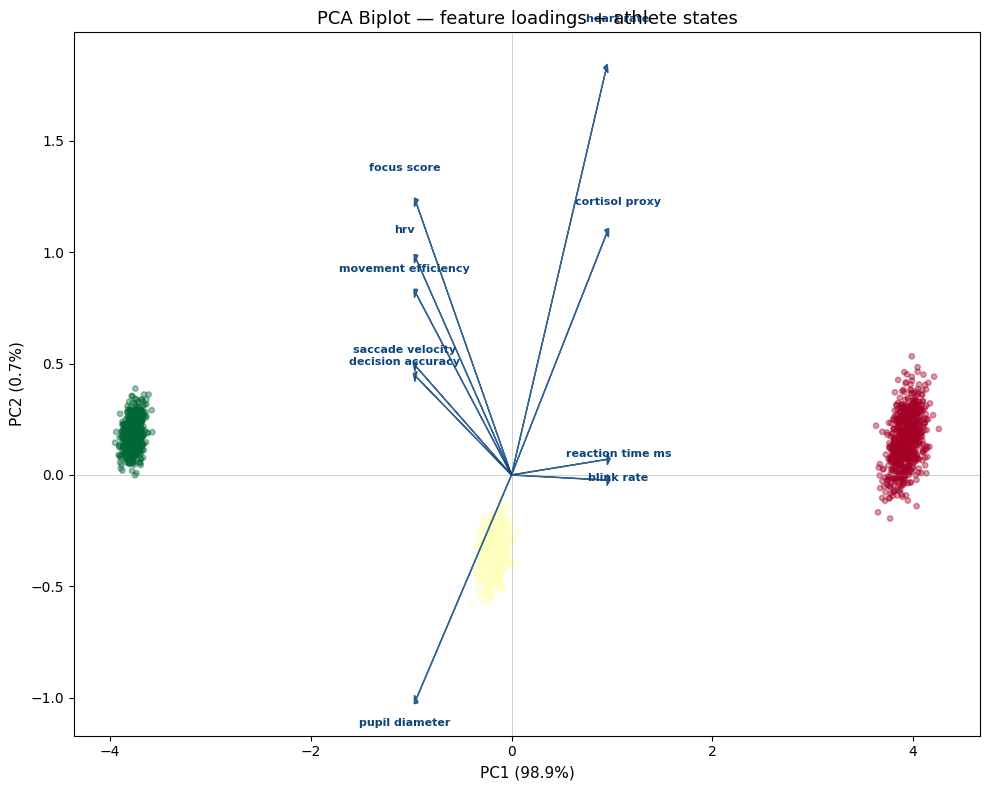

In [5]:
loadings = pca2.components_.T
feat_names = [s.replace("_"," ") for s in SIGNALS]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_2d[:,0], X_2d[:,1],
           c=[{"fatigued":0,"normal":1,"zone":2}[l] for l in labels],
           cmap="RdYlGn", alpha=0.4, s=15)

scale = 3.0
for i, (feat, (lx, ly)) in enumerate(zip(feat_names, loadings)):
    ax.arrow(0, 0, lx*scale, ly*scale,
             head_width=0.05, head_length=0.03,
             fc="#0C447C", ec="#0C447C", alpha=0.8)
    ax.text(lx*scale*1.12, ly*scale*1.12, feat,
            fontsize=8, ha="center", color="#0C447C", fontweight="bold")

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.set_title("PCA Biplot — feature loadings + athlete states", fontsize=13)
ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig("../data/pca_biplot.png", bbox_inches="tight")
plt.show()

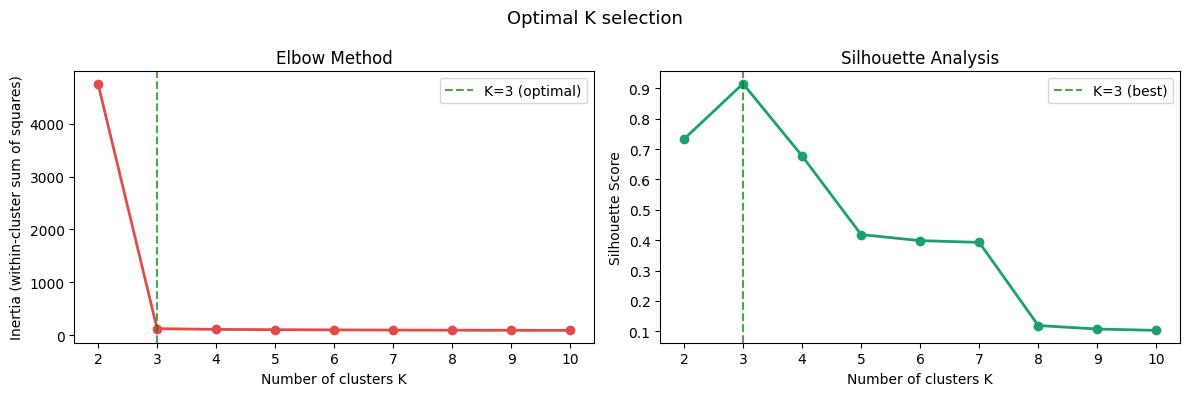


Best silhouette at K=3: 0.916


In [6]:
inertias    = []
silhouettes = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sc, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, "o-", color="#E24B4A", linewidth=2)
ax1.set_xlabel("Number of clusters K")
ax1.set_ylabel("Inertia (within-cluster sum of squares)")
ax1.set_title("Elbow Method")
ax1.axvline(3, color="green", linestyle="--", alpha=0.7, label="K=3 (optimal)")
ax1.legend()

ax2.plot(K_range, silhouettes, "o-", color="#1D9E75", linewidth=2)
ax2.set_xlabel("Number of clusters K")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.axvline(3, color="green", linestyle="--", alpha=0.7, label="K=3 (best)")
ax2.legend()

plt.suptitle("Optimal K selection", fontsize=13)
plt.tight_layout()
plt.savefig("../data/elbow_silhouette.png", bbox_inches="tight")
plt.show()
print(f"\nBest silhouette at K={K_range[np.argmax(silhouettes)]}: "
      f"{max(silhouettes):.3f}")

In [7]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
km3.fit(X_sc)
cluster_labels = km3.labels_

ari = adjusted_rand_score(y, cluster_labels)
sil = silhouette_score(X_sc, cluster_labels)
print(f"Adjusted Rand Index (vs true labels): {ari:.3f}")
print(f"Silhouette Score:                     {sil:.3f}")

cluster_df = df.copy()
cluster_df["cluster"] = cluster_labels

# Map clusters to state names by majority vote
cluster_map = {}
for c in range(3):
    majority = cluster_df[cluster_df["cluster"]==c]["state_label"].mode()[0]
    cluster_map[c] = majority
cluster_df["cluster_name"] = cluster_df["cluster"].map(cluster_map)
print("\nCluster → State mapping:")
print(cluster_df.groupby(["cluster","cluster_name","state_label"]).size().unstack(fill_value=0))

pca3 = PCA(n_components=2, random_state=42)
X_2d3 = pca3.fit_transform(X_sc)

fig = px.scatter(
    x=X_2d3[:,0], y=X_2d3[:,1],
    color=cluster_df["cluster_name"],
    symbol=cluster_df["state_label"],
    color_discrete_map={"zone":"#1D9E75","normal":"#EF9F27","fatigued":"#E24B4A"},
    title=f"K-means ZONE detection (ARI={ari:.3f}, Silhouette={sil:.3f})",
    labels={"x":"PC1","y":"PC2","color":"Detected state","symbol":"True state"},
    opacity=0.7
)
fig.update_traces(marker_size=5)
fig.update_layout(height=500)
fig.show()

Adjusted Rand Index (vs true labels): 1.000
Silhouette Score:                     0.916

Cluster → State mapping:
state_label           fatigued  normal  zone
cluster cluster_name                        
0       normal               0     700     0
1       fatigued           700       0     0
2       zone                 0       0   700


In [8]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.2, min_samples=8)
db_labels = db.fit_predict(X_sc)

n_clusters  = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise     = list(db_labels).count(-1)
print(f"DBSCAN: {n_clusters} clusters, {n_noise} noise points "
      f"({n_noise/len(db_labels)*100:.1f}%)")

fig = px.scatter(
    x=X_2d3[:,0], y=X_2d3[:,1],
    color=db_labels.astype(str),
    title=f"DBSCAN clustering — {n_clusters} clusters, {n_noise} outliers",
    labels={"x":"PC1","y":"PC2","color":"Cluster"},
    opacity=0.7
)
fig.update_traces(marker_size=5)
fig.update_layout(height=450)
fig.show()

DBSCAN: 3 clusters, 0 noise points (0.0%)
